In [105]:
import torch
import checkpoint
import seaborn as sns
import matplotlib.pyplot as plt
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [106]:
easier_val = checkpoint.CheckPoint(path="models/MLC_all_trans_study1_nep20_lr0_0005_bs64_dr0_2_io_easy_val.pt", device=DEVICE)
model = easier_val.load_model()
val = easier_val.load_dataloaders(data_dir="data/all_transformations_study1", use_datasets=["val"])[0]

Loading model that has completed (or started) 20 of 20 epochs
	batch size: 64
	number of steps:57,520
	best val loss achieved: 1.0168
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.2 dropout
Loaded following dataloaders:
val dataloader (n=22,912)


In [107]:
batch = next(iter(val))

In [108]:
batch_size = len(batch['yq'])
xq_context_padded = batch['xq_context_padded'] # batch_size x maxlen_src
src_embed, src_padding_mask = model.prep_encode(xq_context_padded)

emission_lang = val.dataset.langs["output"]
z_padded = torch.tensor([emission_lang.IN_OUT_idx]*batch_size, device=DEVICE)
z_padded = z_padded.unsqueeze(1)
tgt_embed, tgt_padding_mask, tgt_mask = model.prep_decode(z_padded)

trans_out = model.transformer(src_embed, tgt_embed, tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask, tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask)
                 
output = model.out(trans_out)


In [109]:
import torch.nn.functional as F

encoder_layer = model.transformer.encoder.layers[0]
src = src_embed
src_key_padding_mask=src_padding_mask
src_mask = None
src_key_padding_mask = F._canonical_mask(
            mask=src_key_padding_mask,
            mask_name="src_key_padding_mask",
            other_type=F._none_or_dtype(src_mask),
            other_name="src_mask",
            target_type=src.dtype,
        )
src_mask = F._canonical_mask(
    mask=src_mask,
    mask_name="src_mask",
    other_type=None,
    other_name="",
    target_type=src.dtype,
    check_other=False,
)

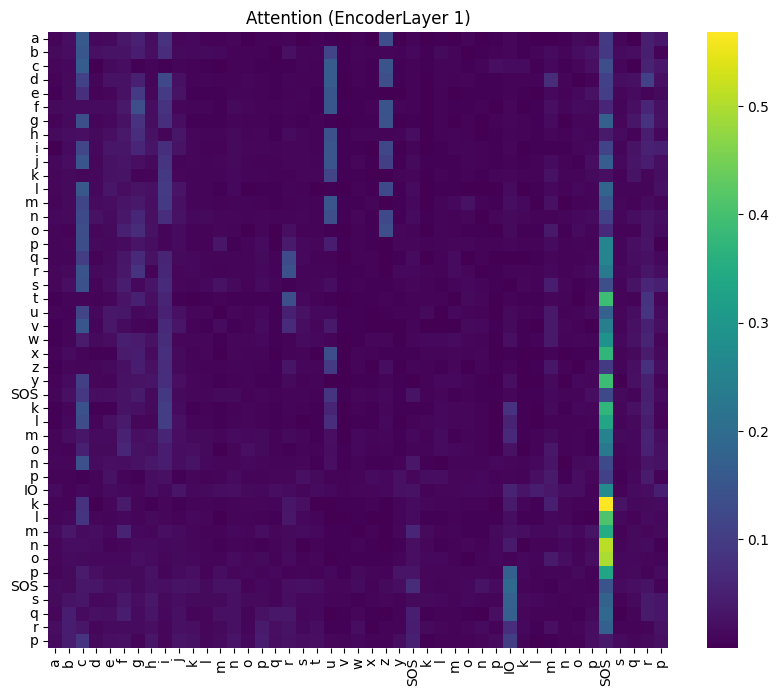

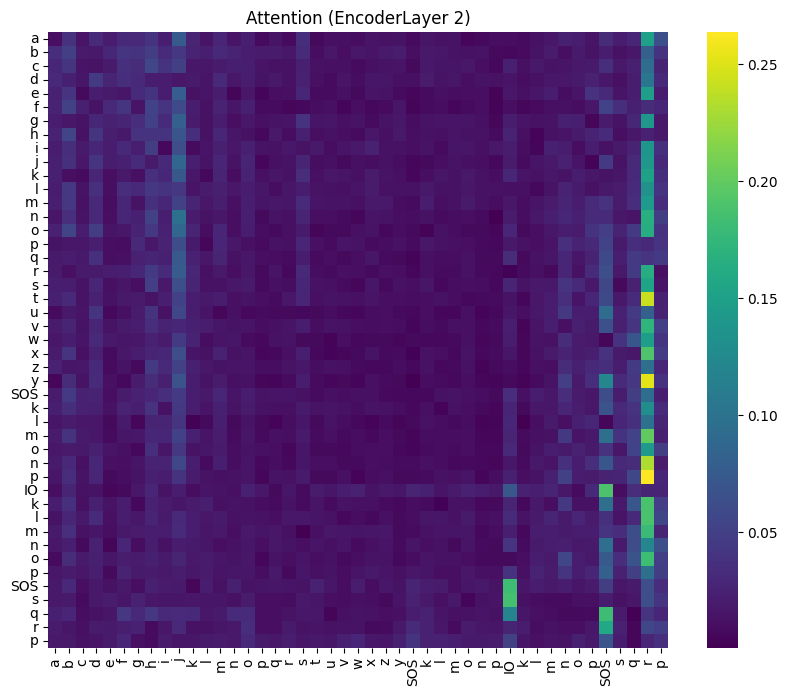

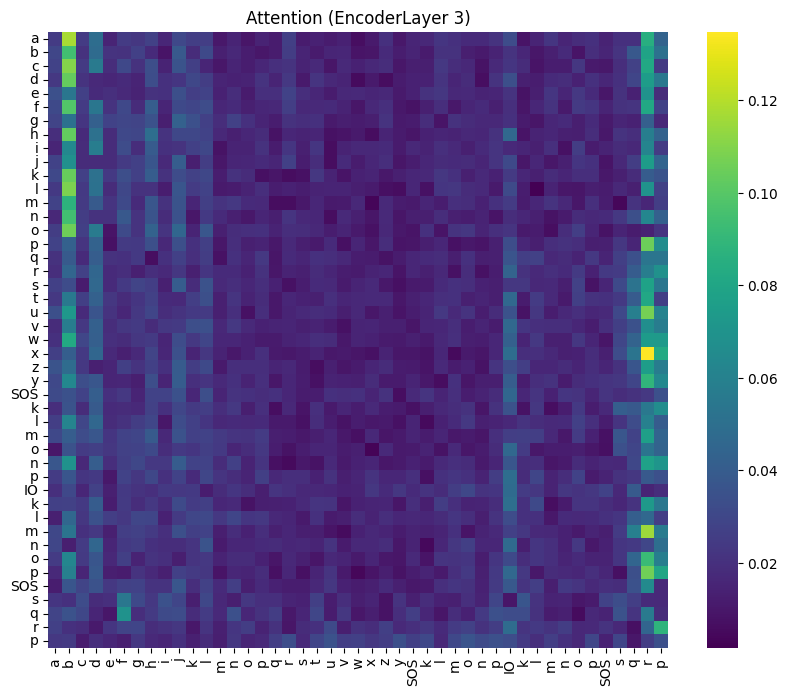

In [110]:
example_idx = 3
for i, layer in enumerate(model.transformer.encoder.layers):
    x = src
    for j in range(0, i):
        x = model.transformer.encoder.layers[j](
            x,
            src_key_padding_mask=src_key_padding_mask)
    # plot attention
    attn_output, attn_output_weights = encoder_layer.self_attn(
    x,
    x,
    x,
    attn_mask=src_mask,
    key_padding_mask=src_key_padding_mask,
    need_weights=True,
    is_causal=False)
    example_length = len(batch["xq_context"][example_idx])
    # Select the first batch and first head
    weights = attn_output_weights[example_idx, :example_length, :example_length].detach().cpu().numpy()  # shape: [seq_len, seq_len]

    plt.figure(figsize=(10, 8))
    sns.heatmap(weights, cmap="viridis", xticklabels=batch["xq_context"][example_idx], yticklabels=batch["xq_context"][example_idx])
    plt.title(f"Attention (EncoderLayer {i+1})")
    plt.show()